In [86]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, confusion_matrix


In [2]:
df = pd.read_csv('dados_credito.csv', encoding='latin1', sep=';')
df


,CODIGO_CLIENTE,UF,IDADE,ESCOLARIDADE,ESTADO_CIVIL,QT_FILHOS,CASA_PROPRIA,QT_IMOVEIS,VL_IMOVEIS,OUTRA_RENDA,OUTRA_RENDA_VALOR,TEMPO_ULTIMO_EMPREGO_MESES,TRABALHANDO_ATUALMENTE,ULTIMO_SALARIO,QT_CARROS,VALOR_TABELA_CARROS,SCORE
0,1,SP,19,Superior Cursando,Solteiro,0,Não,0,0,Não,0,8,Sim,1800,0,0,12
1,2,MG,23,Superior Completo,Solteiro,1,Não,0,0,Não,0,9,Não,4800,1,50000,18
2,3,SC,25,Segundo Grau Completo,Casado,0,Sim,1,220000,Não,0,18,Sim,2200,2,30000,23
3,4,PR,27,Superior Cursando,Casado,1,Sim,0,0,Não,0,22,Não,3900,0,0,29
4,5,RJ,28,Superior Completo,Divorciado,2,Não,1,370000,Não,0,30,Sim,NaN,1,35000,34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10471,10472,PR,51,Superior Completo,Solteiro,1,Não,0,0,Não,0,9,Não,4800,1,50000,18
10472,10473,SP,48,Segundo Grau Completo,Casado,0,Sim,1,220000,Não,0,18,Sim,2200,2,30000,23
10473,10474,RJ,51,Superior Cursando,Casado,1,Sim,0,0,Não,0,22,Não,3900,0,0,29
10474,10475,RJ,48,Superior Completo,Divorciado,2,Não,1,370000,Não,0,30,Sim,NaN,1,35000,34


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10476 entries, 0 to 10475
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   CODIGO_CLIENTE              10476 non-null  int64
 1   UF                          10476 non-null  str  
 2   IDADE                       10476 non-null  int64
 3   ESCOLARIDADE                10476 non-null  str  
 4   ESTADO_CIVIL                10476 non-null  str  
 5   QT_FILHOS                   10476 non-null  int64
 6   CASA_PROPRIA                10476 non-null  str  
 7   QT_IMOVEIS                  10476 non-null  int64
 8   VL_IMOVEIS                  10476 non-null  int64
 9   OUTRA_RENDA                 10476 non-null  str  
 10  OUTRA_RENDA_VALOR           10476 non-null  int64
 11  TEMPO_ULTIMO_EMPREGO_MESES  10476 non-null  int64
 12  TRABALHANDO_ATUALMENTE      10476 non-null  str  
 13  ULTIMO_SALARIO              10474 non-null  str  
 14  QT_CARROS        

In [4]:
df.drop('CODIGO_CLIENTE', axis=1, inplace=True)

In [5]:
df.groupby('ULTIMO_SALARIO').size()

ULTIMO_SALARIO
11500        790
13000        522
15000        522
17500        522
1800         846
18300        522
2200         792
22000        468
3100         792
3900         792
4500         468
4800         792
5300         522
6100         522
6800         611
9000         522
9800         468
SEM DADOS      1
dtype: int64

In [6]:
df.replace('SEM DADOS', np.nan, inplace=True)

,UF,IDADE,ESCOLARIDADE,ESTADO_CIVIL,QT_FILHOS,CASA_PROPRIA,QT_IMOVEIS,VL_IMOVEIS,OUTRA_RENDA,OUTRA_RENDA_VALOR,TEMPO_ULTIMO_EMPREGO_MESES,TRABALHANDO_ATUALMENTE,ULTIMO_SALARIO,QT_CARROS,VALOR_TABELA_CARROS,SCORE
0,SP,19,Superior Cursando,Solteiro,0,Não,0,0,Não,0,8,Sim,1800,0,0,12
1,MG,23,Superior Completo,Solteiro,1,Não,0,0,Não,0,9,Não,4800,1,50000,18
2,SC,25,Segundo Grau Completo,Casado,0,Sim,1,220000,Não,0,18,Sim,2200,2,30000,23
3,PR,27,Superior Cursando,Casado,1,Sim,0,0,Não,0,22,Não,3900,0,0,29
4,RJ,28,Superior Completo,Divorciado,2,Não,1,370000,Não,0,30,Sim,NaN,1,35000,34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10471,PR,51,Superior Completo,Solteiro,1,Não,0,0,Não,0,9,Não,4800,1,50000,18
10472,SP,48,Segundo Grau Completo,Casado,0,Sim,1,220000,Não,0,18,Sim,2200,2,30000,23
10473,RJ,51,Superior Cursando,Casado,1,Sim,0,0,Não,0,22,Não,3900,0,0,29
10474,RJ,48,Superior Completo,Divorciado,2,Não,1,370000,Não,0,30,Sim,NaN,1,35000,34


In [7]:
df['ULTIMO_SALARIO'] = df['ULTIMO_SALARIO'].astype(float)

In [8]:
df.isnull().sum()

UF                            0
IDADE                         0
ESCOLARIDADE                  0
ESTADO_CIVIL                  0
QT_FILHOS                     0
CASA_PROPRIA                  0
QT_IMOVEIS                    0
VL_IMOVEIS                    0
OUTRA_RENDA                   0
OUTRA_RENDA_VALOR             0
TEMPO_ULTIMO_EMPREGO_MESES    0
TRABALHANDO_ATUALMENTE        0
ULTIMO_SALARIO                3
QT_CARROS                     0
VALOR_TABELA_CARROS           0
SCORE                         0
dtype: int64

In [9]:
df.describe()

,IDADE,QT_FILHOS,QT_IMOVEIS,VL_IMOVEIS,OUTRA_RENDA_VALOR,TEMPO_ULTIMO_EMPREGO_MESES,ULTIMO_SALARIO,QT_CARROS,VALOR_TABELA_CARROS,SCORE
count,10476.000000,10476.000000,10476.000000,10476.000000,10476.000000,10476.000000,10473.000000,10476.000000,10476.000000,10476.000000
mean,41.054124,1.122566,0.847079,238453.608247,641.237113,43.070447,8287.157452,0.936426,40996.563574,51.134021
std,13.878162,1.113537,0.957374,265843.934416,1295.978195,40.851521,5827.306760,0.806635,47404.214062,27.324857
min,19.000000,0.000000,0.000000,0.000000,0.000000,8.000000,1800.000000,0.000000,0.000000,12.000000
25%,28.000000,0.000000,0.000000,0.000000,0.000000,14.000000,3900.000000,0.000000,0.000000,29.000000
50%,42.000000,1.000000,1.000000,185000.000000,0.000000,22.000000,6100.000000,1.000000,35000.000000,45.000000
75%,53.000000,2.000000,1.000000,370000.000000,0.000000,75.000000,11500.000000,2.000000,50000.000000,73.000000
max,65.000000,42.000000,3.000000,900000.000000,4000.000000,150.000000,22000.000000,2.000000,180000.000000,98.000000


In [10]:
val_mum = []
for i in df.columns[0:16]:
    if df.dtypes[i] == 'float64' or df.dtypes[i] == 'int64':
        val_mum.append(i)
val_mum

['IDADE',
 'QT_FILHOS',
 'QT_IMOVEIS',
 'VL_IMOVEIS',
 'OUTRA_RENDA_VALOR',
 'TEMPO_ULTIMO_EMPREGO_MESES',
 'ULTIMO_SALARIO',
 'QT_CARROS',
 'VALOR_TABELA_CARROS',
 'SCORE']

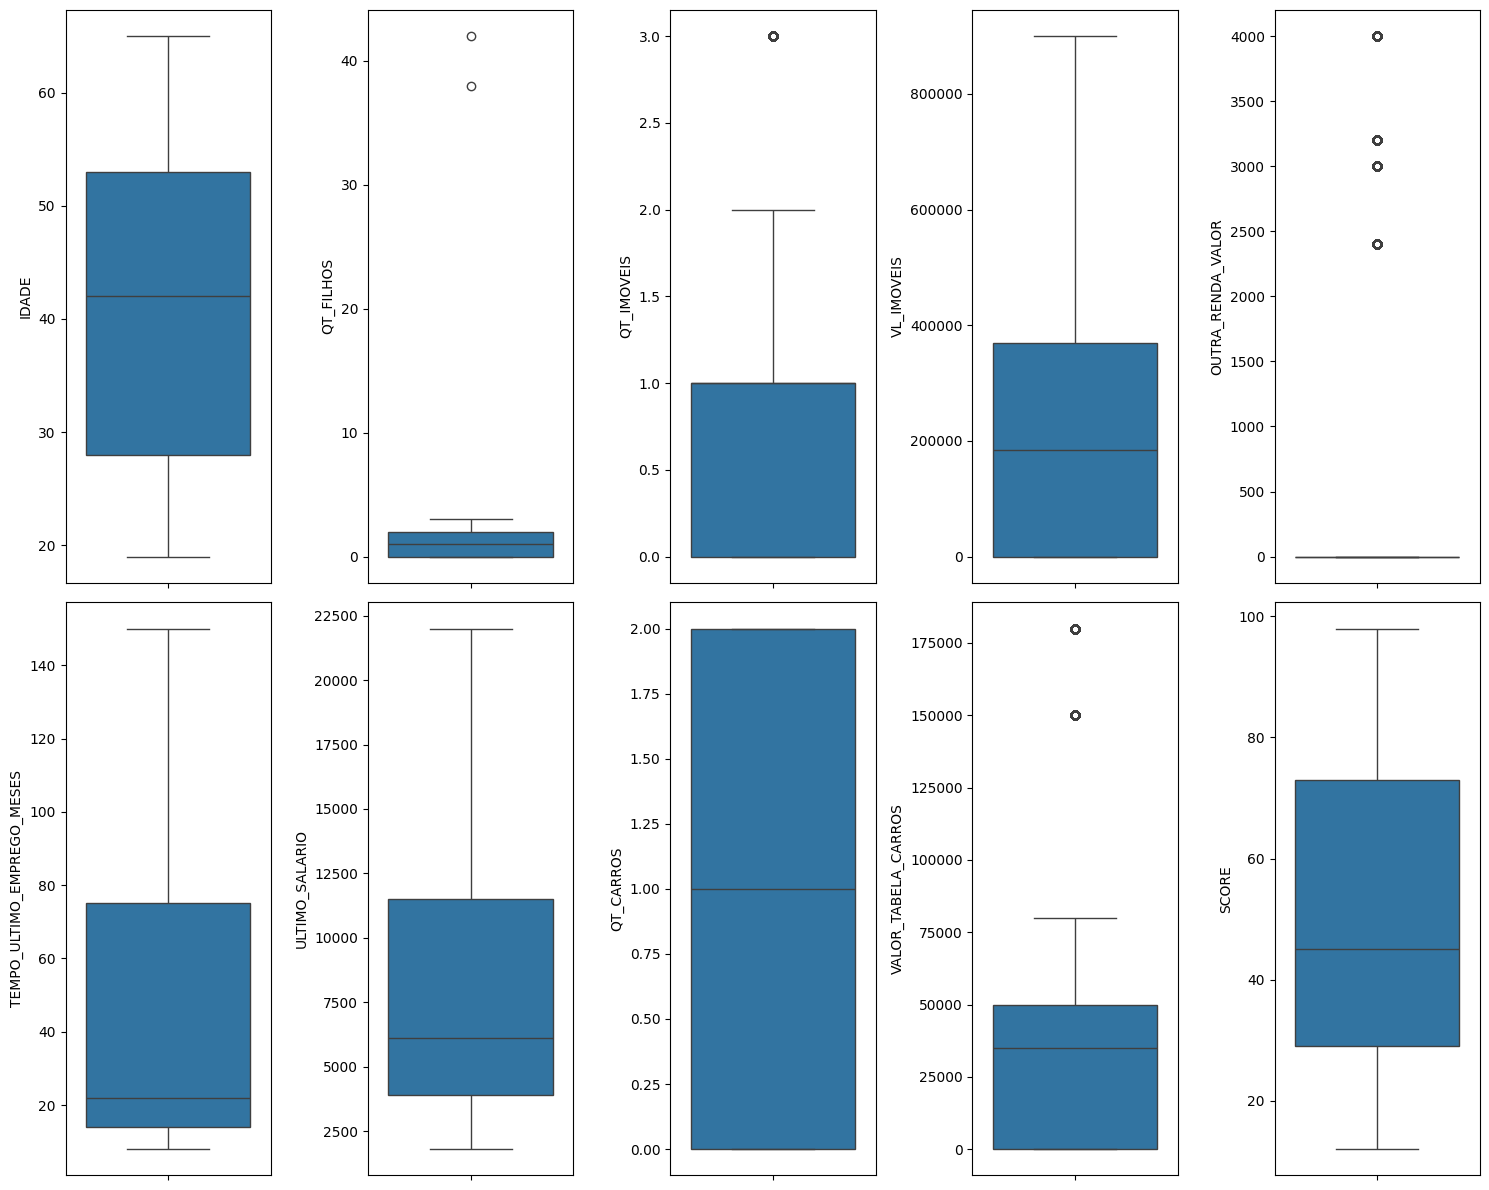

In [11]:
plt.rcParams['figure.figsize'] = (15, 12)
plt.rcParams['figure.autolayout'] = True

f, ax = plt.subplots(2, 5)

linha = 0
coluna = 0

for i in val_mum:
    sns.boxplot(data=df, y=i, ax=ax[linha][coluna])
    coluna += 1
    if coluna == 5:
        linha += 1
        coluna = 0


In [12]:
df.loc[df['QT_FILHOS'] > 4]

,UF,IDADE,ESCOLARIDADE,ESTADO_CIVIL,QT_FILHOS,CASA_PROPRIA,QT_IMOVEIS,VL_IMOVEIS,OUTRA_RENDA,OUTRA_RENDA_VALOR,TEMPO_ULTIMO_EMPREGO_MESES,TRABALHANDO_ATUALMENTE,ULTIMO_SALARIO,QT_CARROS,VALOR_TABELA_CARROS,SCORE
27,SP,48,Superior Completo,Divorciado,38,Sim,2,600000,Não,0,15,Sim,15000.0,1,70000,67
10455,SP,45,Segundo Grau Completo,Casado,42,Sim,1,220000,Não,0,18,Sim,2200.0,2,30000,23


In [13]:
df.drop(df.loc[df['QT_FILHOS'] > 4].index, inplace=True)

In [14]:
df.groupby('QT_IMOVEIS').size()

QT_IMOVEIS
0    4680
1    3761
2     989
3    1044
dtype: int64

In [15]:
df.groupby('OUTRA_RENDA_VALOR').size()

OUTRA_RENDA_VALOR
0       8350
2400     468
3000     612
3200     522
4000     522
dtype: int64

In [16]:
df.groupby('VALOR_TABELA_CARROS').size()

VALOR_TABELA_CARROS
0         3762
28000      468
30000      791
35000      792
40000      792
48000      522
50000     1314
70000      521
80000      522
150000     468
180000     522
dtype: int64

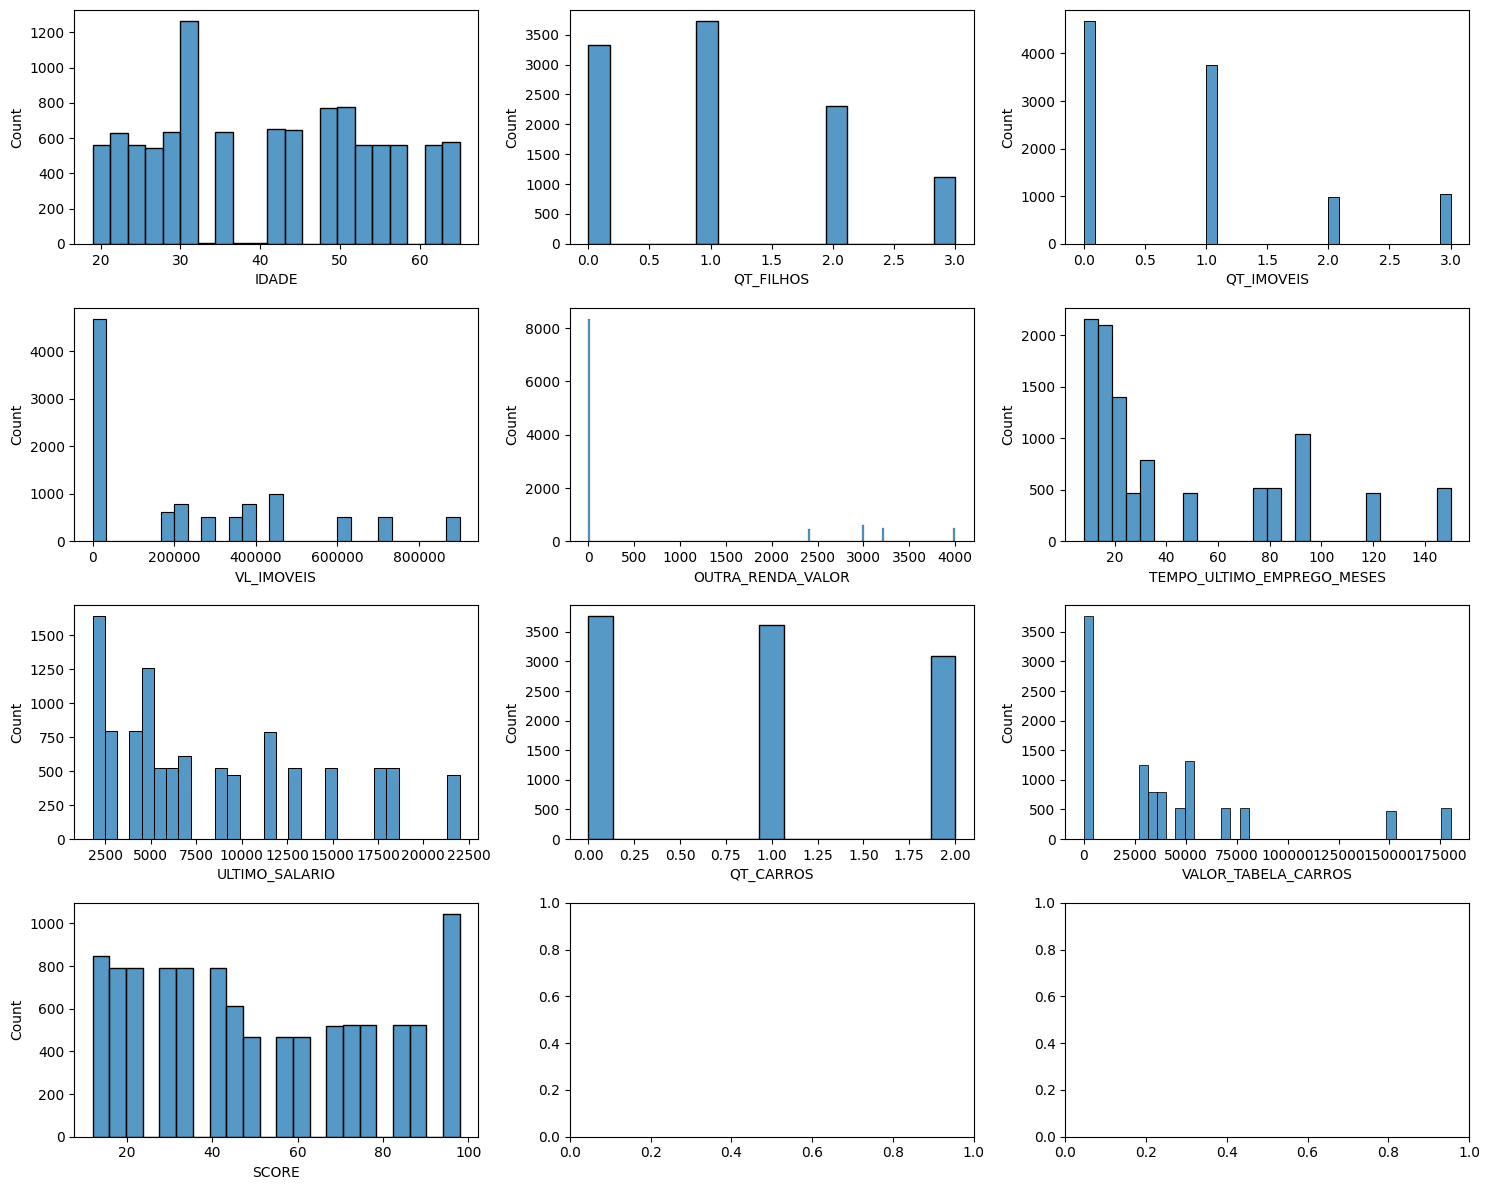

In [17]:
plt.rcParams['figure.figsize'] = (15, 12)
plt.rcParams['figure.autolayout'] = True

f, ax = plt.subplots(4, 3)

linha = 0
coluna = 0

for i in val_mum:
    sns.histplot(data=df, x=i, ax=ax[linha][coluna])
    coluna += 1
    if coluna == 3:
        linha += 1
        coluna = 0

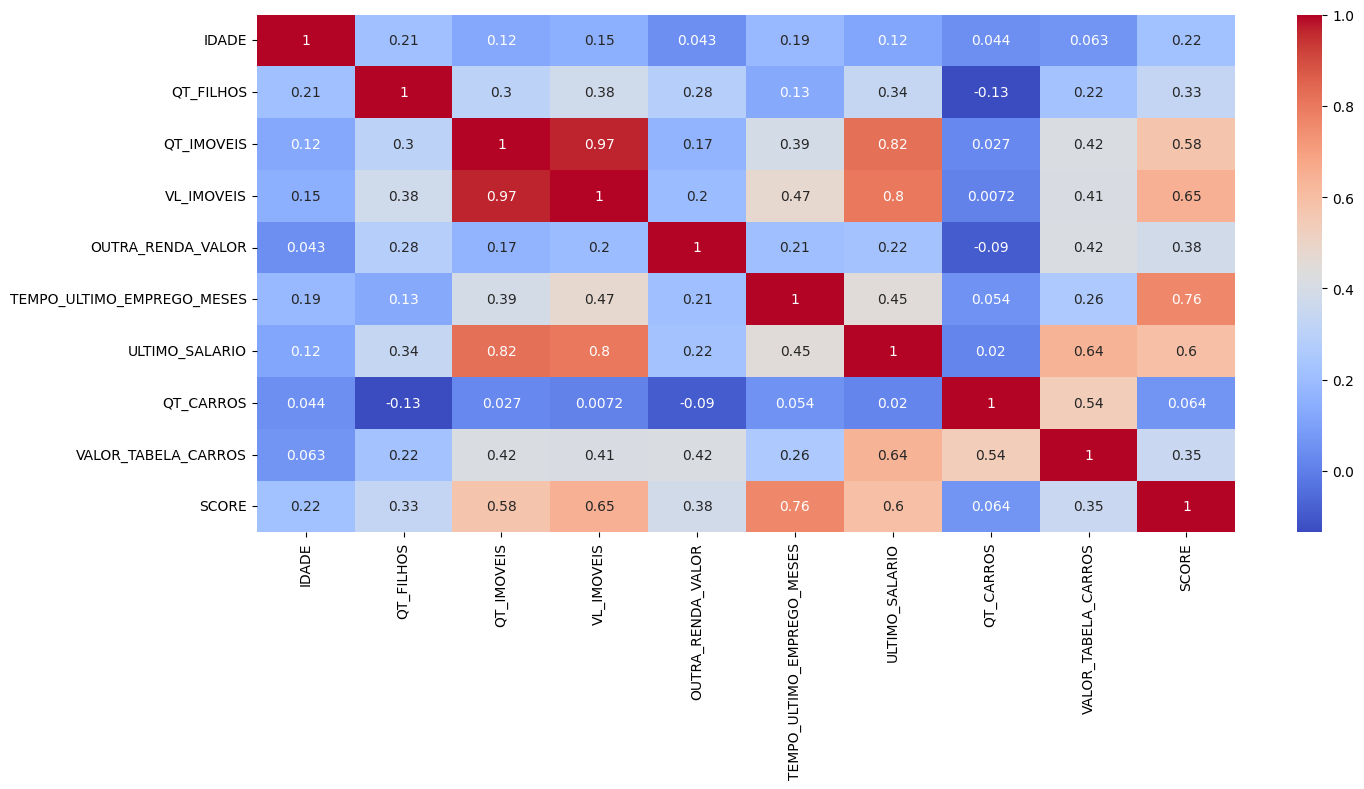

In [18]:
plt.rcParams['figure.figsize'] = (15, 8)
ax = sns.heatmap(df.select_dtypes(include=['float64', 'int64']).corr(), annot=True, cmap='coolwarm')


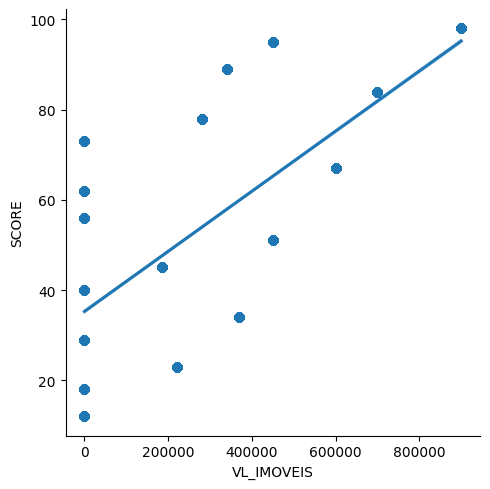

In [19]:
sns.lmplot(x='VL_IMOVEIS', y='SCORE', data=df)


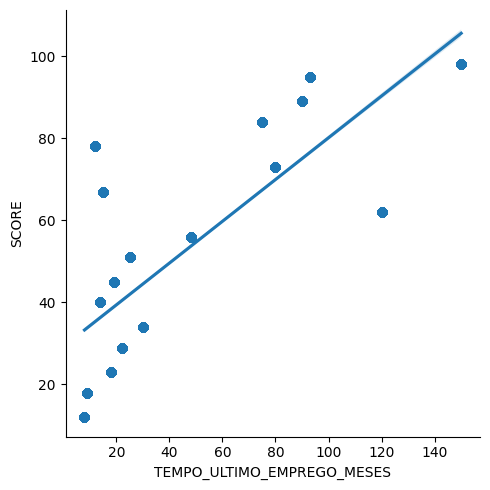

In [20]:
sns.lmplot(x='TEMPO_ULTIMO_EMPREGO_MESES', y='SCORE', data=df)

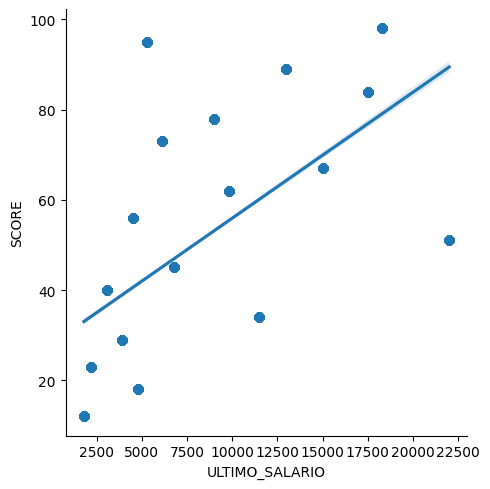

In [21]:
sns.lmplot(x='ULTIMO_SALARIO', y='SCORE', data=df)

In [22]:
display(df.IDADE.min())
display(df.IDADE.max())

np.int64(19)

np.int64(65)

In [23]:
idades = [0, 30, 40, 50, 60]
categoria_idade = ['19-30', '31-40', '41-50', '50+']

df['FAIXA_ETARIA'] = pd.cut(df.IDADE, bins=idades, labels=categoria_idade, include_lowest=True)
df['FAIXA_ETARIA'].value_counts()

FAIXA_ETARIA
19-30    3552
50+      2448
41-50    2070
31-40    1270
Name: count, dtype: int64

In [24]:
df.groupby(['FAIXA_ETARIA'])['SCORE'].mean()

FAIXA_ETARIA
19-30    44.837838
31-40    48.963780
41-50    51.507246
50+      56.198529
Name: SCORE, dtype: float64

In [25]:
df.groupby(['FAIXA_ETARIA'])['SCORE'].median()

FAIXA_ETARIA
19-30    34.0
31-40    45.0
41-50    56.0
50+      59.0
Name: SCORE, dtype: float64

In [26]:
val_cat = []
for i in df.columns[0:18].tolist():
    if df[i].dtype == 'str' or df[i].dtype == 'category':
        val_cat.append(i)
val_cat

['UF',
 'ESCOLARIDADE',
 'ESTADO_CIVIL',
 'CASA_PROPRIA',
 'OUTRA_RENDA',
 'TRABALHANDO_ATUALMENTE',
 'FAIXA_ETARIA']

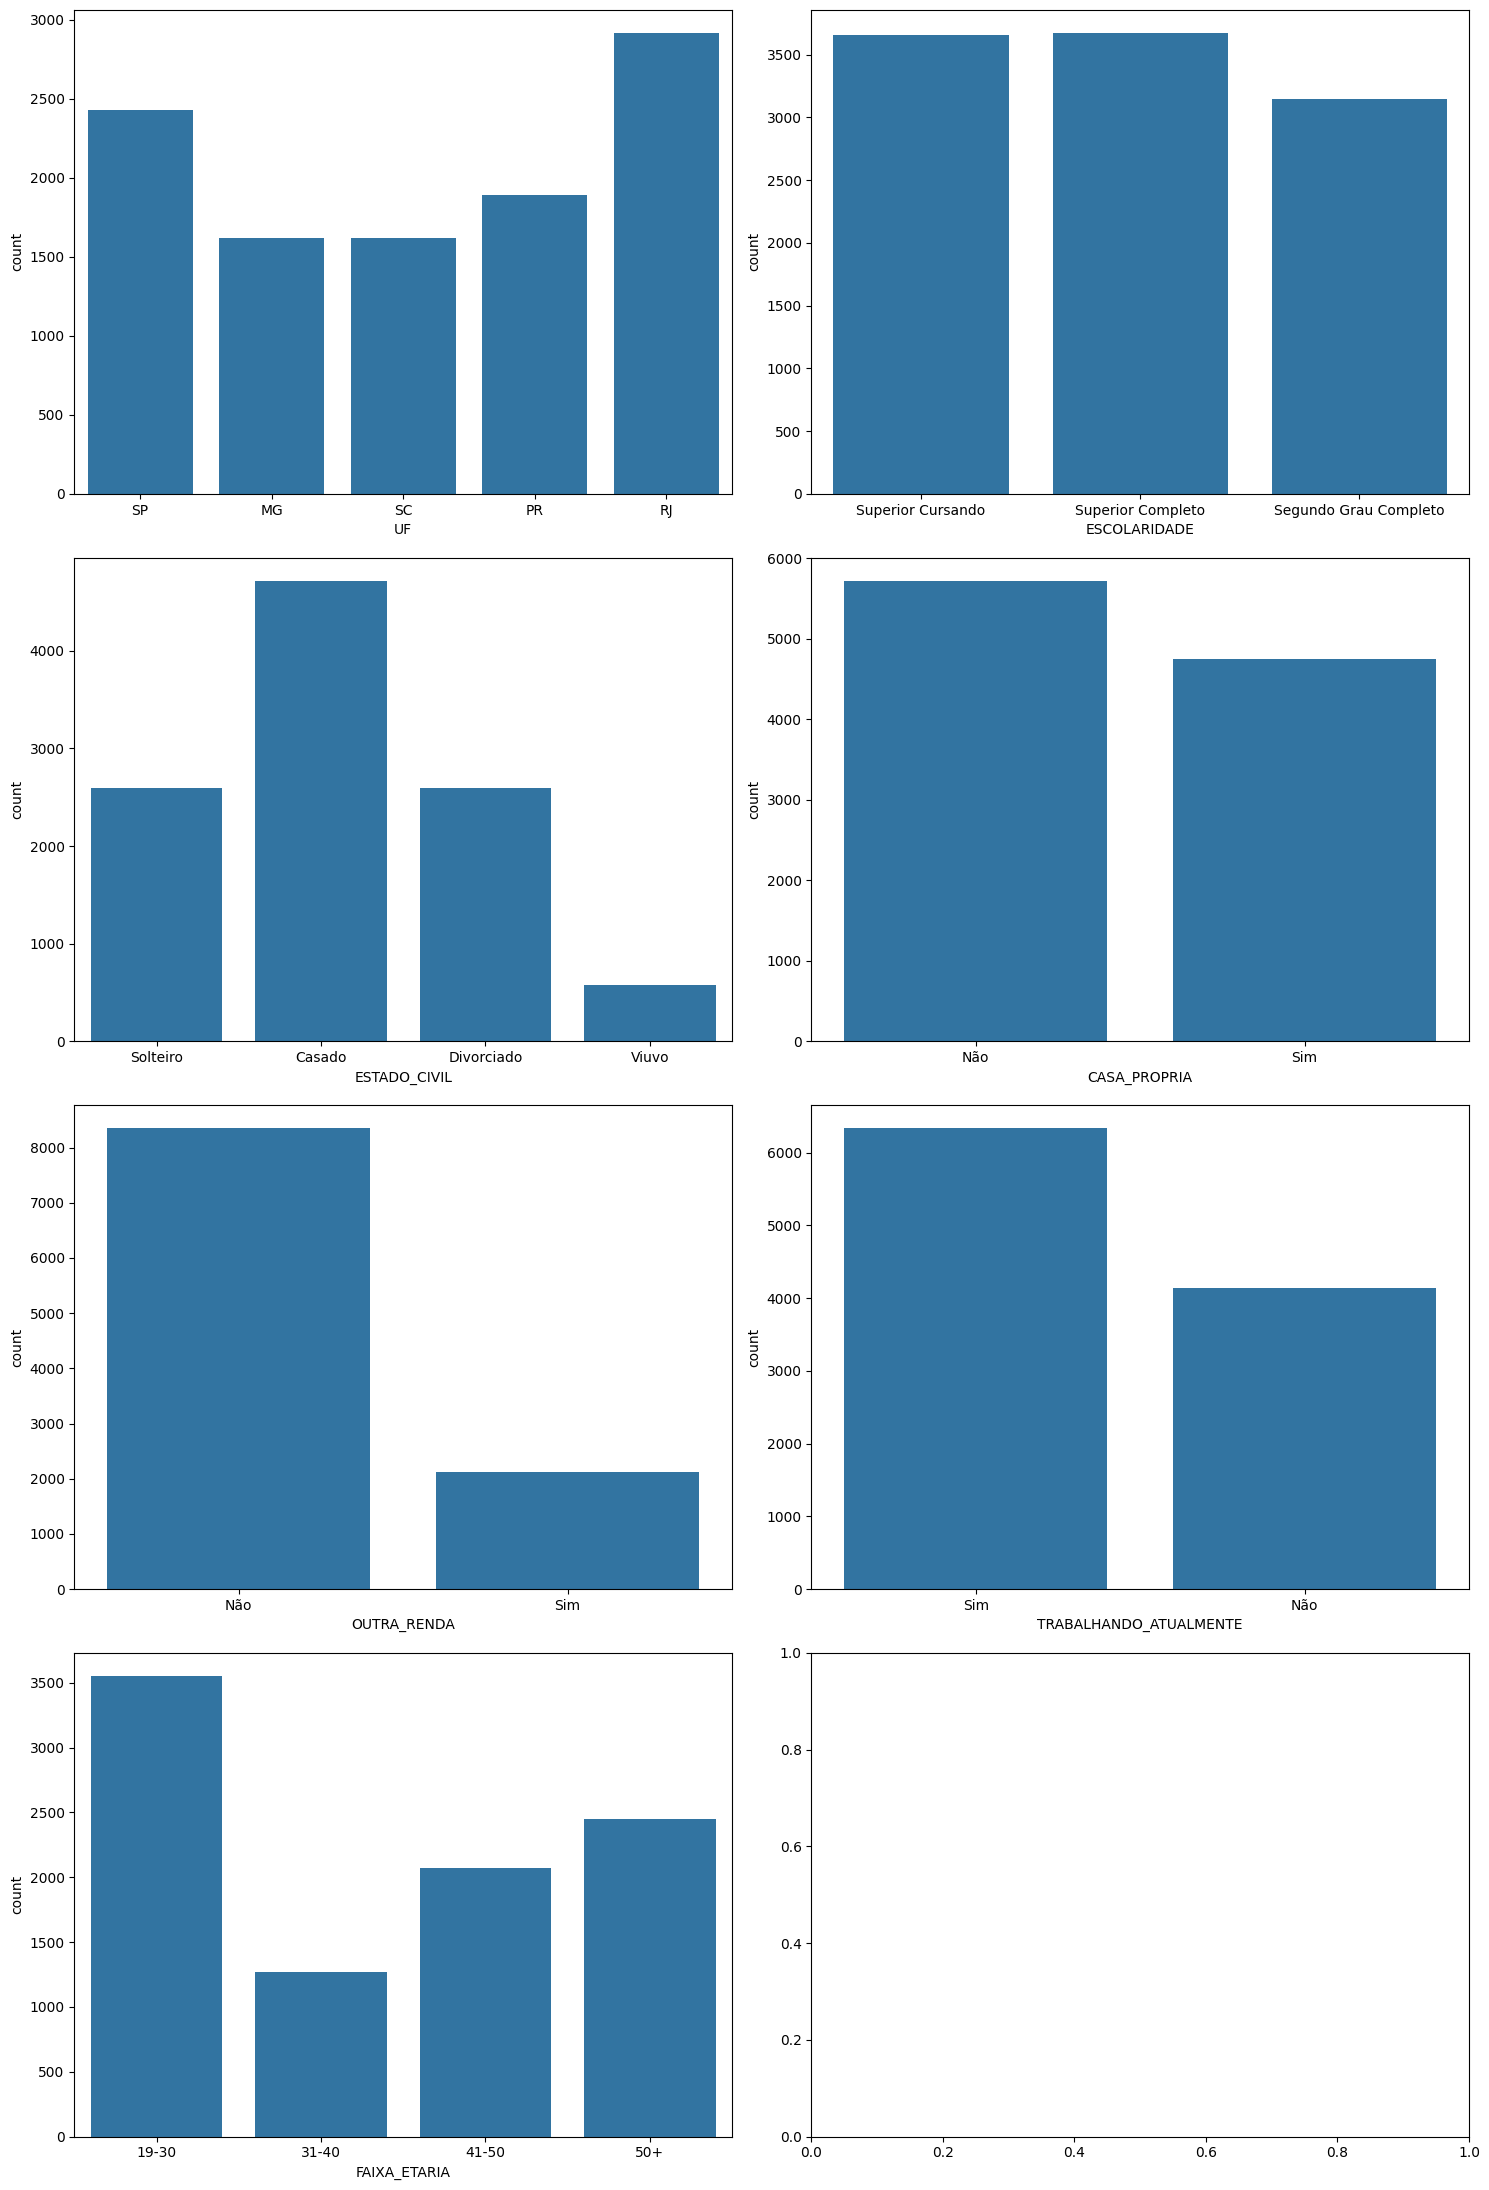

In [28]:
plt.rcParams['figure.figsize'] = (15, 22)
plt.rcParams['figure.autolayout'] = True

f, ax = plt.subplots(4, 2)

linha = 0
coluna = 0

for i in val_cat:
    sns.countplot(data=df, x=i, ax=ax[linha][coluna])
    coluna += 1
    if coluna == 2:
        linha += 1
        coluna = 0

In [29]:
lb = LabelEncoder()

In [30]:
df['CASA_PROPRIA'] = lb.fit_transform(df['CASA_PROPRIA'])
df['ESCOLARIDADE'] = lb.fit_transform(df['ESCOLARIDADE'])
df['ESTADO_CIVIL'] = lb.fit_transform(df['ESTADO_CIVIL'])
df['FAIXA_ETARIA'] = lb.fit_transform(df['FAIXA_ETARIA'])
df['OUTRA_RENDA'] = lb.fit_transform(df['OUTRA_RENDA'])
df['TRABALHANDO_ATUALMENTE'] = lb.fit_transform(df['TRABALHANDO_ATUALMENTE'])
df['UF'] = lb.fit_transform(df['UF'])

df.dropna(inplace=True)
df.info()

<class 'pandas.DataFrame'>
Index: 10471 entries, 0 to 10475
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   UF                          10471 non-null  int64  
 1   IDADE                       10471 non-null  int64  
 2   ESCOLARIDADE                10471 non-null  int64  
 3   ESTADO_CIVIL                10471 non-null  int64  
 4   QT_FILHOS                   10471 non-null  int64  
 5   CASA_PROPRIA                10471 non-null  int64  
 6   QT_IMOVEIS                  10471 non-null  int64  
 7   VL_IMOVEIS                  10471 non-null  int64  
 8   OUTRA_RENDA                 10471 non-null  int64  
 9   OUTRA_RENDA_VALOR           10471 non-null  int64  
 10  TEMPO_ULTIMO_EMPREGO_MESES  10471 non-null  int64  
 11  TRABALHANDO_ATUALMENTE      10471 non-null  int64  
 12  ULTIMO_SALARIO              10471 non-null  float64
 13  QT_CARROS                   10471 non-null  int

In [59]:
df_data = df.iloc[:-20]

df_val = df.tail(20)

target = df_data.iloc[:,15:16]

preditoras = df_data.copy()

del preditoras['SCORE']

In [51]:
X_treino, X_teste, y_treino, y_teste = train_test_split(preditoras, target, test_size= 0.3, random_state=42)

In [52]:
sc = MinMaxScaler()
X_treino_normalizado = sc.fit_transform(X_treino)
X_teste_normalizado = sc.transform(X_teste)


In [53]:
modelo = LinearRegression()
modelo.fit(X_treino_normalizado, y_treino)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [54]:
r2_score(y_teste, modelo.fit(X_treino_normalizado, y_treino).predict(X_teste_normalizado))

0.8109477767573154

In [80]:
coluna = "SCORE"
cols = [c for c in df_val.columns if c != coluna] + [coluna]
df_val = df_val[cols]

df_new = df_val.iloc[:,0:16]
df_con = df_val['SCORE']

In [81]:
x =np.array(df_new)
x = sc.transform(x)

previsao = modelo.predict(x)
print(modelo.predict(x))


[[11.29935797]
 [24.01229153]
 [31.49531809]
 [60.70003284]
 [30.31176009]
 [49.99088544]
 [49.9198338 ]
 [71.40475371]
 [58.9028059 ]
 [60.73569794]
 [45.61893646]
 [84.02616157]
 [91.30708874]
 [86.296533  ]
 [99.30293933]
 [11.92201416]
 [24.06482231]
 [35.15503169]
 [34.52861879]
 [31.32328038]]


In [ ]:
r2_score(np.array(df_con), previsao)

0.8344572523707794